<a href="https://colab.research.google.com/github/Alek-2321/Trabalho_Machine_Learning_F.Posser/blob/main/machine_learning_trabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import zipfile

In [42]:
path_crime = "/content/31154657-spj-dados-abertos-ocorrencias-jan-dez-2025-em-05-01-2026.zip"
path_meteo = "/content/INMET cidades jan 2021 - ago 2025-20260407T131547Z-3-001.zip"

In [83]:
with zipfile.ZipFile(path_crime, 'r') as z:
    print("Arquivos dentro do ZIP:", z.namelist())

    arquivo_crime = z.namelist()[0]

    df_crime = pd.read_csv(
        z.open(arquivo_crime),
        sep=';',
        encoding='latin1',
        low_memory=False
    )

print(df_crime.head())
print(df_crime.info())

Arquivos dentro do ZIP: ['SPJ_DADOS_ABERTOS_OCORRÊNCIAS_JAN_DEZ_2025 - Em 05.01.2026.csv']
   Sequência   Data Fato Hora Fato     Grupo Fato  \
0          1  01/01/2025  00:01:00  CONTRAVENCOES   
1          2  01/01/2025  00:01:00         CRIMES   
2          3  01/01/2025  00:01:00         CRIMES   
3          4  01/01/2025  00:01:00         CRIMES   
4          5  01/01/2025  00:01:00         CRIMES   

                              Tipo Enquadramento  Tipo Fato Municipio Fato  \
0  PERTURBACAO DO TRABALHO OU DO SOSSEGO ALHEIOS  Consumado  CAXIAS DO SUL   
1                              FURTO QUALIFICADO  Consumado       PIRATINI   
2                               FURTO EM VEICULO  Consumado         TORRES   
3                                         AMEACA  Consumado      TRAMANDAI   
4           APROPRIACAO INDEBITA DE BEM DE IDOSO  Consumado        ERECHIM   

    Local Fato        Bairro  Quantidade Vítimas  ...  Unnamed: 171  \
0       OUTROS     Pedancino                 1.0  

In [43]:
import os

# Extrair só o arquivo de Passo Fundo
with zipfile.ZipFile(path_meteo, 'r') as z:
    file = [f for f in z.namelist() if "PASSO FUNDO" in f.upper()][0]
    z.extract(file, "/content")


file_path = os.path.join("/content", file)

print(file_path)

/content/INMET cidades jan 2021 - ago 2025/PASSO FUNDO - dados_A839_D_2021-01-01_2025-09-05.csv


In [44]:
with open(file_path, 'r', encoding='latin1') as f:
    for i, linha in enumerate(f):
        if "Data" in linha:
            print("Linha correta:", i) #Encontrar a linha que começa a coluna DATA.
            print(linha)
            break

Linha correta: 6
Data Inicial: 2021-01-01



In [45]:
df_meteo = pd.read_csv(
    file_path,
    sep=';',
    encoding='latin1',
    skiprows=8, # Mesmo a linha correta sendo 6, coloquei 8 pois pelo cabeçalho do arquivo pode ter variância.
    engine='python',
    decimal=',',
    on_bad_lines='skip',
    header=0
)

print(df_meteo.head())
print(df_meteo.info())

                                                                                                                                                                                                                       Periodicidade da Medicao: Diaria
Data Medicao PRECIPITACAO TOTAL, DIARIO (AUT)(mm) TEMPERATURA MAXIMA, DIARIA (AUT)(Â°C) TEMPERATURA MINIMA, DIARIA (AUT)(Â°C) UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%) VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)                               NaN
2021-01-01   0                                    27.5                                  14.7                                  65                                            2.4                                                                     NaN
2021-01-02   0                                    28.4                                  16.3                                  55.8                                          3.8                                                                     NaN
2021-01-

In [46]:
df_meteo = df_meteo.reset_index()

In [47]:
print(df_meteo.head())

        level_0                               level_1  \
0  Data Medicao  PRECIPITACAO TOTAL, DIARIO (AUT)(mm)   
1    2021-01-01                                     0   
2    2021-01-02                                     0   
3    2021-01-03                                     0   
4    2021-01-04                                     0   

                                 level_2  \
0  TEMPERATURA MAXIMA, DIARIA (AUT)(Â°C)   
1                                   27.5   
2                                   28.4   
3                                   28.5   
4                                   28.8   

                                 level_3  \
0  TEMPERATURA MINIMA, DIARIA (AUT)(Â°C)   
1                                   14.7   
2                                   16.3   
3                                   15.4   
4                                   15.6   

                                         level_4  \
0  UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)   
1                      

Limpeza das ocorrências

In [48]:
# Removemos colunas desnecessárias (as que vêm como "Unnamed"),
# pois não agregam valor na análise e só poluem o dataset
df_crime = df_crime.loc[:, ~df_crime.columns.str.contains('^Unnamed')]

In [49]:
# Padronizamos os nomes das colunas para facilitar o uso no código
df_crime.columns = df_crime.columns.str.strip().str.lower()

In [70]:
!pip install unidecode

In [87]:
#Sempre que houver espaços, substituir por "_" para não ter que mudar sempre.
import unidecode

df_crime.columns = [
    unidecode.unidecode(col).strip().lower().replace(" ", "_")
    for col in df_crime.columns
]

In [86]:
print (df_crime)

        Sequência   Data Fato Hora Fato     Grupo Fato  \
0               1  01/01/2025  00:01:00  CONTRAVENCOES   
1               2  01/01/2025  00:01:00         CRIMES   
2               3  01/01/2025  00:01:00         CRIMES   
3               4  01/01/2025  00:01:00         CRIMES   
4               5  01/01/2025  00:01:00         CRIMES   
...           ...         ...       ...            ...   
763790     763791  31/12/2025  23:50:00         CRIMES   
763791     763792  31/12/2025  23:50:00         CRIMES   
763792     763793  31/12/2025  23:55:00         CRIMES   
763793     763794  31/12/2025  23:55:00         CRIMES   
763794     763795  31/12/2025  23:59:03  CONTRAVENCOES   

                                   Tipo Enquadramento  Tipo Fato  \
0       PERTURBACAO DO TRABALHO OU DO SOSSEGO ALHEIOS  Consumado   
1                                   FURTO QUALIFICADO  Consumado   
2                                    FURTO EM VEICULO  Consumado   
3                              

In [88]:
# Convertendo a coluna de data para o formato datetime,
# permitindo trabalhar com datas corretamente
df_crime['data'] = pd.to_datetime(
    df_crime['data_fato'],
    format='%d/%m/%Y',
    errors='coerce'
)

In [89]:
# Filtramos apenas os dados do município de Passo Fundo,
# pois esse é o foco da análise
df_crime = df_crime[df_crime['municipio_fato'].str.contains('PASSO FUNDO', na=False)]

In [74]:
# Selecionamos apenas as colunas relevantes para a análise
df_crime = df_crime[[
    'data',
    'tipo_fato',
    'grupo_fato',
    'bairro'
]]

In [75]:
# Padronizamos os textos (tudo minúsculo e sem espaços extras),
# evitando inconsistências como "Crime" vs "crime"
for col in ['tipo_fato', 'grupo_fato', 'bairro']:
    df_crime[col] = df_crime[col].str.strip().str.lower()

In [76]:
# Removemos registros sem data, pois não podem ser analisados no tempo
df_crime = df_crime.dropna(subset=['data'])

In [77]:
# Removemos duplicatas para evitar contagem incorreta de ocorrências
df_crime = df_crime.drop_duplicates()

Limpeza dados meteorológicos

In [78]:
# Removemos colunas vazias ou irrelevantes (como "Unnamed")
df_meteo = df_meteo.loc[:, ~df_meteo.columns.str.contains('^Unnamed')]

In [91]:
# Renomeamos as colunas para nomes mais simples e padronizados
df_meteo.columns = [
    'data',
    'precipitacao',
    'temp_max',
    'temp_min',
    'umidade',
    'vento',
    'lixo',

]


In [92]:
# Convertendo a coluna de data para formato datetime
df_meteo['data'] = pd.to_datetime(df_meteo['data'], errors='coerce')

/tmp/ipykernel_3958/3847428362.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_meteo['data'] = pd.to_datetime(df_meteo['data'], errors='coerce')


In [93]:
# Convertendo as colunas numéricas, pois vieram como texto do arquivo original
for col in ['precipitacao', 'temp_max', 'temp_min', 'umidade', 'vento']:
    df_meteo[col] = pd.to_numeric(df_meteo[col], errors='coerce')

In [94]:
# Removemos registros sem data
df_meteo = df_meteo.dropna(subset=['data'])

In [ ]:
# Removemos duplicatas
df_meteo = df_meteo.drop_duplicates()

Agora o resultado

In [95]:
# Convertendo as datas para o mesmo formato (apenas dia),
# garantindo que os dois datasets possam ser integrados corretamente
df_crime['data'] = pd.to_datetime(df_crime['data'], errors='coerce')
df_meteo['data'] = pd.to_datetime(df_meteo['data'], errors='coerce')

/tmp/ipykernel_3958/3672997491.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meteo['data'] = pd.to_datetime(df_meteo['data'], errors='coerce')


In [96]:
df_crime['data'] = df_crime['data'].dt.date
df_meteo['data'] = df_meteo['data'].dt.date

/tmp/ipykernel_3958/3781084429.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meteo['data'] = df_meteo['data'].dt.date


In [97]:
# Resultado dos tratamentos
print(df_crime.info())
print(df_meteo.info())

<class 'pandas.core.frame.DataFrame'>
Index: 15810 entries, 46 to 763761
Columns: 182 entries, sequencia to data
dtypes: float64(58), int64(1), object(123)
memory usage: 22.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 1709 entries, 1 to 1709
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   data          1709 non-null   object 
 1   precipitacao  1644 non-null   float64
 2   temp_max      1662 non-null   float64
 3   temp_min      1660 non-null   float64
 4   umidade       1677 non-null   float64
 5   vento         1649 non-null   float64
 6   lixo          0 non-null      float64
dtypes: float64(6), object(1)
memory usage: 106.8+ KB
None


In [98]:
# Realizamos o merge dos dois datasets utilizando a coluna "data" como chave
# Usamos o tipo "inner" para manter apenas os registros que existem em ambos
df_final = pd.merge(df_crime, df_meteo, on='data', how='inner')

# Verificamos o resultado da junção
print(df_final.shape)
print(df_final.head())

(10757, 188)
   sequencia   data_fato hora_fato grupo_fato  \
0         47  01/01/2025  00:01:00     CRIMES   
1        145  01/01/2025  00:30:00     CRIMES   
2        212  01/01/2025  01:00:44     CRIMES   
3        294  01/01/2025  02:00:00     CRIMES   
4        400  01/01/2025  02:45:01     CRIMES   

                              tipo_enquadramento  tipo_fato municipio_fato  \
0                                  FURTO SIMPLES  Consumado    PASSO FUNDO   
1                                 LESAO CORPORAL  Consumado    PASSO FUNDO   
2                                        CALUNIA  Consumado    PASSO FUNDO   
3  LESAO CORPORAL CULPOSA DIRECAO VEIC AUTOMOTOR  Consumado    PASSO FUNDO   
4                                         AMEACA  Consumado    PASSO FUNDO   

                  local_fato                 bairro  quantidade_vitimas  ...  \
0  ESTABELECIMENTO COMERCIAL                 Centro                 1.0  ...   
1                VIA PUBLICA          Parque do Sol            

In [105]:
df_final.head()

,sequencia,data_fato,hora_fato,grupo_fato,tipo_enquadramento,tipo_fato,municipio_fato,local_fato,bairro,quantidade_vitimas,...,unnamed:_178,unnamed:_179,unnamed:_180,data,precipitacao,temp_max,temp_min,umidade,vento,lixo
0,47,01/01/2025,00:01:00,CRIMES,FURTO SIMPLES,Consumado,PASSO FUNDO,ESTABELECIMENTO COMERCIAL,Centro,1.0,...,NaN,NaN,NaN,2025-01-01,0.2,30.0,17.9,76.7,3.5,NaN
1,145,01/01/2025,00:30:00,CRIMES,LESAO CORPORAL,Consumado,PASSO FUNDO,VIA PUBLICA,Parque do Sol,1.0,...,NaN,NaN,NaN,2025-01-01,0.2,30.0,17.9,76.7,3.5,NaN
2,212,01/01/2025,01:00:44,CRIMES,CALUNIA,Consumado,PASSO FUNDO,OUTROS,José Alexandre Zachia,1.0,...,NaN,NaN,NaN,2025-01-01,0.2,30.0,17.9,76.7,3.5,NaN
3,294,01/01/2025,02:00:00,CRIMES,LESAO CORPORAL CULPOSA DIRECAO VEIC AUTOMOTOR,Consumado,PASSO FUNDO,VIA PUBLICA,Centro,2.0,...,NaN,NaN,NaN,2025-01-01,0.2,30.0,17.9,76.7,3.5,NaN
4,400,01/01/2025,02:45:01,CRIMES,AMEACA,Consumado,PASSO FUNDO,OUTROS,Vila Vera Cruz,1.0,...,NaN,NaN,NaN,2025-01-01,0.2,30.0,17.9,76.7,3.5,NaN


Quantidade de crimes por dia

In [109]:
# Agrupamos os dados por data para calcular a quantidade de crimes por dia
# e associar com as médias das variáveis climáticas
df_analise = df_final.groupby('data').agg({
    'tipo_fato': 'count',
    'precipitacao': 'mean',
    'temp_max': 'mean',
    'temp_min': 'mean',
    'umidade': 'mean',
    'vento': 'mean',
    'lixo' : 'mean',
}).reset_index()

# Renomeamos a coluna para deixar mais claro o significado
df_analise = df_analise.rename(columns={'tipo_fato': 'qtd_crimes'})

In [110]:
df_analise.head()

,data,qtd_crimes,precipitacao,temp_max,temp_min,umidade,vento,lixo
0,2025-01-01,44,0.2,30.0,17.9,76.7,3.5,NaN
1,2025-01-02,44,14.0,28.8,17.3,81.5,2.5,NaN
2,2025-01-03,28,4.0,29.7,18.7,65.1,2.4,NaN
3,2025-01-04,29,0.0,25.9,14.9,50.2,2.0,NaN
4,2025-01-05,29,0.0,27.1,13.9,56.6,1.9,NaN


Detecção de outliers

Outliers foram identificados com base no intervalo interquartil (IQR), representando dias com volume anormalmente alto de ocorrências

In [111]:
# Utilizamos o método do IQR para identificar valores fora do padrão
q1 = df_analise['qtd_crimes'].quantile(0.25)
q3 = df_analise['qtd_crimes'].quantile(0.75)
iqr = q3 - q1

# Definimos o limite superior para identificar outliers
limite_sup = q3 + 1.5 * iqr

# Filtramos os dias com quantidade de crimes acima do esperado
outliers = df_analise[df_analise['qtd_crimes'] > limite_sup]

print(outliers)

          data  qtd_crimes  precipitacao  temp_max  temp_min  umidade  vento  \
35  2025-02-05          65           0.0      33.1      19.6     67.1    2.7   
40  2025-02-10          71           0.2      35.1      21.0     64.3    2.8   
82  2025-03-24          65           0.0      31.5      18.6     70.1    1.8   

    lixo  
35   NaN  
40   NaN  
82   NaN  


In [112]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_analise[['temp_max', 'temp_min', 'umidade', 'vento']] = scaler.fit_transform(
    df_analise[['temp_max', 'temp_min', 'umidade', 'vento']]
)


In [113]:
df_analise.head()

,data,qtd_crimes,precipitacao,temp_max,temp_min,umidade,vento,lixo
0,2025-01-01,44,0.2,0.812500,0.836134,0.591518,0.442308,NaN
1,2025-01-02,44,14.0,0.768382,0.810924,0.698661,0.250000,NaN
2,2025-01-03,28,4.0,0.801471,0.869748,0.332589,0.230769,NaN
3,2025-01-04,29,0.0,0.661765,0.710084,0.000000,0.153846,NaN
4,2025-01-05,29,0.0,0.705882,0.668067,0.142857,0.134615,NaN


Gráficos

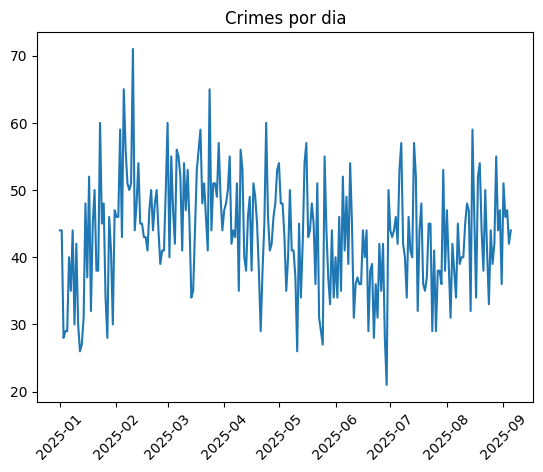

In [114]:
# Gráfico de linha para visualizar a evolução dos crimes ao longo do tempo
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_analise['data'], df_analise['qtd_crimes'])
plt.title("Crimes por dia")
plt.xticks(rotation=45)
plt.show()

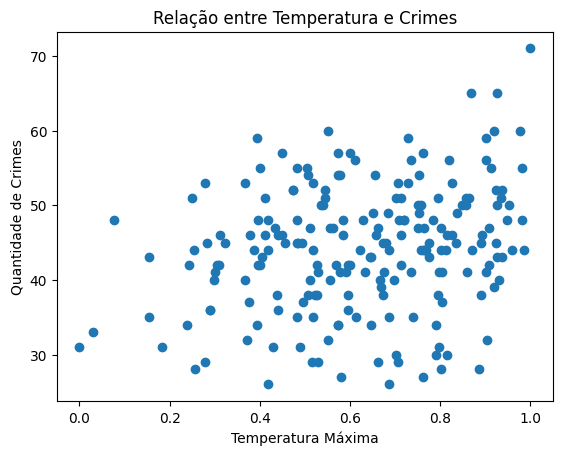

In [115]:
# Gráfico de dispersão para analisar relação entre temperatura e crimes
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_analise['temp_max'], df_analise['qtd_crimes'])
plt.xlabel("Temperatura Máxima")
plt.ylabel("Quantidade de Crimes")
plt.title("Relação entre Temperatura e Crimes")
plt.show()

In [116]:
# Calculamos a correlação entre as variáveis numéricas
correlacao = df_analise.corr(numeric_only=True)

# Visualizamos a relação com a quantidade de crimes
print(correlacao['qtd_crimes'])

qtd_crimes      1.000000
precipitacao   -0.024506
temp_max        0.250388
temp_min        0.222995
umidade        -0.083762
vento          -0.027780
lixo                 NaN
Name: qtd_crimes, dtype: float64
